# Viscoelastic earthquake cycle model demo

This notebook compares **VECycle interseismic Green's functions** with **homogeneous half-space Green's functions** using the same interface geometry for inversion.

## Notebook goals
- Build native VECycle Green's functions once (slow step).
- Reassemble forward-cycle/interseismic Green's functions for different earthquake-cycle timing parameters (fast step).
- Compare forward surface velocities between homogeneous and viscoelastic models.
- Invert synthetic observations with both models and compare fit quality and inferred slip.

## Prerequisites
- The `geoslip2d` package is available in your active Python environment.
- This notebook is run from the GeoSlip2D repository (or one level below it), so paths resolve correctly.

## Recommended run order
1. Run all cells once from top to bottom.
2. To test new cycle timing parameters (`forward_tR`, `forward_teq`, `forward_T`), rerun only the fast forward-cycle cell and all cells after it.
3. Rebuild the slow native VECycle step only if geometry parameters change (dip, depths, wedge geometry, patch length).

![Interface Geometry](./images/cycle_interface.png)

In [1]:
# import standard libraries

from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import geoslip2d as gs2d


cwd = Path.cwd().resolve()
if (cwd / "src" / "geoslip2d").is_dir():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

OUTPUT_DIR = PROJECT_ROOT / "Geodesy_TSC" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")



PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D
OUTPUT_DIR   = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D/Geodesy_TSC/outputs


In [2]:
from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)

## 1. Define geometry and observation grid

This section sets the geometric parameters and the surface observation positions used throughout the notebook.

What this cell does:
- Defines a requested interface geometry (used as fallback/shared geometry).
- Defines `xobs`, the horizontal observation coordinates used for plotting and inversion.
- Plots the requested interface so you can verify geometry before expensive computations.

InterfaceGeometry(n_patch=40, x=[0, 305] km, z=[-0, 83.4] km)


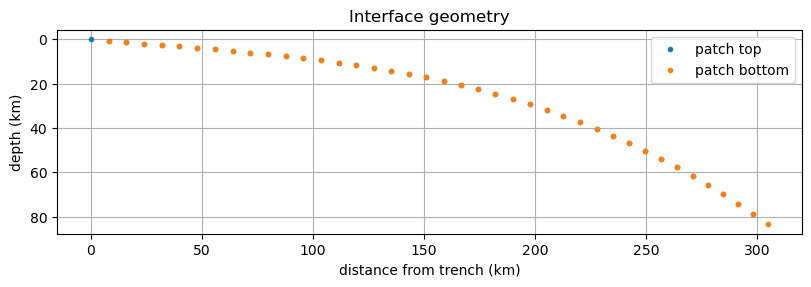

In [3]:
faultdip_trench = 5.0
faultdip_bottom = 35.0
x_trench = 0.0
x_bottom = 300.0
z_bottom = 80.0
patch_length = 8.0

xobs = np.linspace(100, 500.0, 300)
locking_depth_km = 40.0
backslip_rate = 1.0

# Fallback/shared geometry for plotting and for passing requested geometry parameters.
requested_interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=faultdip_trench,
    x_trench=x_trench,
    x_bottom=x_bottom,
    faultdip_bottom=faultdip_bottom,
    z_bottom=z_bottom,
    patch_length=patch_length,
)
print(requested_interface.summary())
fig = gs2d.plot_interface(requested_interface)
plt.show()

## 2. Build and refresh Green's functions

This workflow is split into two stages:

- **Slow stage (native build):** computes native VECycle Green's functions from the geometry. This can take minutes.
- **Fast stage (forward-cycle assembly):** combines native responses using cycle timing parameters to form interseismic Green's functions. This is fast and is intended for parameter sweeps.

Parameter guidance for the fast stage:
- `forward_tR`: viscoelastic relaxation time scale (years).
- `forward_teq`: time since last earthquake (years).
- `forward_T`: recurrence interval (years).

Important: the fast-stage output is interpolated to `xobs` so model predictions and plotting arrays stay aligned.

Building raw Green's-function blocks...
Source 1/11 code='1': 207 of 207 patches
Source 2/11 code='2': 200 of 200 patches
Source 3/11 code='3': 5 of 5 patches
Source 4/11 code='4': 5 of 5 patches
Source 5/11 code='5': 4 of 4 patches
Source 6/11 code='6': 238 of 238 patches
Source 7/11 code='7': 200 of 200 patches
Source 8/11 code='8': 250 of 250 patches
Source 9/11 code='b': 99 of 99 patches
Source 10/11 code='t': 62 of 62 patches
Source 11/11 code='i': 40 of 40 patches
Compiling linear-system matrices...
Cycle source 1 of 40
Cycle source 2 of 40
Cycle source 3 of 40
Cycle source 4 of 40
Cycle source 5 of 40
Cycle source 6 of 40
Cycle source 7 of 40
Cycle source 8 of 40
Cycle source 9 of 40
Cycle source 10 of 40
Cycle source 11 of 40
Cycle source 12 of 40
Cycle source 13 of 40
Cycle source 14 of 40
Cycle source 15 of 40
Cycle source 16 of 40
Cycle source 17 of 40
Cycle source 18 of 40
Cycle source 19 of 40
Cycle source 20 of 40
Cycle source 21 of 40
Cycle source 22 of 40
Cycle source 2

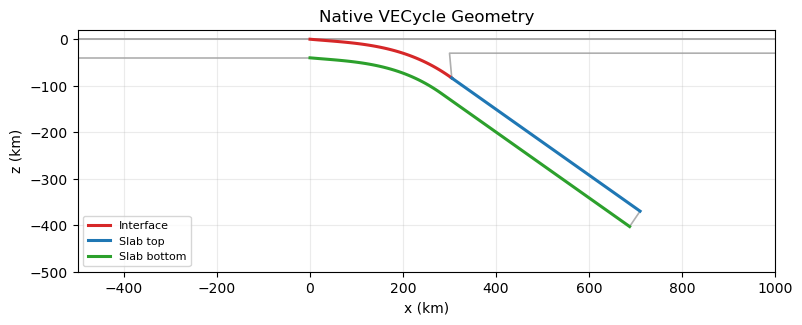

In [4]:
# SLOW STEP: build native VECycle Green's functions once for the chosen geometry.
# Re-run this cell only when geometry-related parameters are changed.
from types import SimpleNamespace
from geoslip2d.vecycle2d import default_config as vecycle_default_config
from geoslip2d.vecycle2d import build_greens as build_native_vecycle_greens
from geoslip2d.vecycle2d.forward import ForwardConfig, assemble_interseismic_greens

native_cfg = vecycle_default_config()
native_cfg.geometry.faultdip_trench = faultdip_trench
native_cfg.geometry.faultdip_bottom = faultdip_bottom
native_cfg.geometry.x_trench = x_trench
native_cfg.geometry.x_bottom = x_bottom
native_cfg.geometry.wedge_bot = z_bottom
native_cfg.geometry.pL = patch_length
native_cfg.geometry.wedge_top_x = 300.0
native_cfg.geometry.L_slab = 500.0

native_greens = build_native_vecycle_greens(native_cfg, progress=True)

# Optional diagnostic plot: reconstruct and display native VECycle boundaries.
from geoslip2d.vecycle2d.geometry import make_wedge_geometry

g = native_greens.Geometry
cfg_geom = vecycle_default_config()
cfg_geom.geometry.faultdip_trench = float(g.faultdip_trench)
cfg_geom.geometry.faultdip_bottom = float(g.faultdip_bottom)
cfg_geom.geometry.x_trench = float(g.x_trench)
cfg_geom.geometry.x_bottom = float(g.x_bottom)
cfg_geom.geometry.wedge_bot = float(g.wedge_bot)
cfg_geom.geometry.pL = float(g.pL)
cfg_geom.geometry.wedge_top_x = float(g.wedge_top_x)
cfg_geom.geometry.L_slab = float(g.L_slab)
cfg_geom.geometry.H_elastic_left = float(g.H_elastic_left)
cfg_geom.geometry.H_elastic_right = float(g.H_elastic_right)

geom_native = make_wedge_geometry(cfg_geom)
geom_native.interface.topz = geom_native.interface.topz - 1e5
geom_native.interface.botz = geom_native.interface.botz - 1e5

fig, ax = plt.subplots(figsize=(9, 4.8))

# Plot all native boundaries.
for b in geom_native.boundaries:
    x = np.r_[b.topx, b.botx[-1]]
    z = np.r_[b.topz, b.botz[-1]] + 1e5
    ax.plot(x, z, color="0.65", lw=1.2, alpha=0.9)

# Highlight interface and slab boundaries.
for b, color, label in [
    (geom_native.interface, "tab:red", "Interface"),
    (geom_native.slab_top, "tab:blue", "Slab top"),
    (geom_native.slab_bottom, "tab:green", "Slab bottom"),
]:
    x = np.r_[b.topx, b.botx[-1]]
    z = np.r_[b.topz, b.botz[-1]] + 1e5
    ax.plot(x, z, color=color, lw=2.2, label=label)

plt.axis("equal")
plt.xlim(-500, 1000)
plt.ylim(-500, 20)

ax.set_title("Native VECycle Geometry")
ax.set_xlabel("x (km)")
ax.set_ylabel("z (km)")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)
plt.show()

In [5]:
# FAST STEP: assemble interseismic/cycle Green's functions from native_greens.
# Re-run this cell when changing forward-cycle timing parameters.
forward_tR = 10.0  # relaxation time scale
forward_teq = 500.0  # time since last earthquake (years)
forward_T = 550.0  # earthquake recurrence time (years)

fwd_cfg = ForwardConfig(tR_scale=forward_tR, teq=forward_teq, T=forward_T)
inter = assemble_interseismic_greens(native_greens, fwd_cfg)
native_for_conversion = SimpleNamespace(
    xpos=native_greens.xpos,
    Geometry=native_greens.Geometry,
    interseismic_greens=inter,
    greens=native_greens,
)

greens_nonhom = gs2d.vecycle_greens_from_native(
    native_for_conversion,
    component="interseismic",
    fallback_interface=requested_interface,
    output_sign=-1.0,
    metadata={"mode": "build_once_forward_refreshable"},
)

# Interpolate to the notebook observation grid so forward modeling and plots align.
greens_nonhom = greens_nonhom.interp_to(xobs)

# Build homogeneous Greens on the same interface for a direct apples-to-apples comparison.
interface = greens_nonhom.interface
print("Actual VECycle comparison interface:")
print(interface.summary())

greens_hom = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    length_override=None,
    progress=True,
    output_sign=-1.0,
)

Actual VECycle comparison interface:
InterfaceGeometry(n_patch=40, x=[-0.000586, 305] km, z=[0.00577, 83.4] km)
completed 1 of 40 patches
completed 2 of 40 patches
completed 3 of 40 patches
completed 4 of 40 patches
completed 5 of 40 patches
completed 6 of 40 patches
completed 7 of 40 patches
completed 8 of 40 patches
completed 9 of 40 patches
completed 10 of 40 patches
completed 11 of 40 patches
completed 12 of 40 patches
completed 13 of 40 patches
completed 14 of 40 patches
completed 15 of 40 patches
completed 16 of 40 patches
completed 17 of 40 patches
completed 18 of 40 patches
completed 19 of 40 patches
completed 20 of 40 patches
completed 21 of 40 patches
completed 22 of 40 patches
completed 23 of 40 patches
completed 24 of 40 patches
completed 25 of 40 patches
completed 26 of 40 patches
completed 27 of 40 patches
completed 28 of 40 patches
completed 29 of 40 patches
completed 30 of 40 patches
completed 31 of 40 patches
completed 32 of 40 patches
completed 33 of 40 patches
comple

## 3. Forward model: uniform backslip above locking depth

This section defines a simple synthetic slip pattern and computes the predicted surface velocities for both models.

What to check:
- The two curves may differ in amplitude/shape due to viscoelastic effects.
- Both are evaluated on the same `xobs` grid for direct comparison.

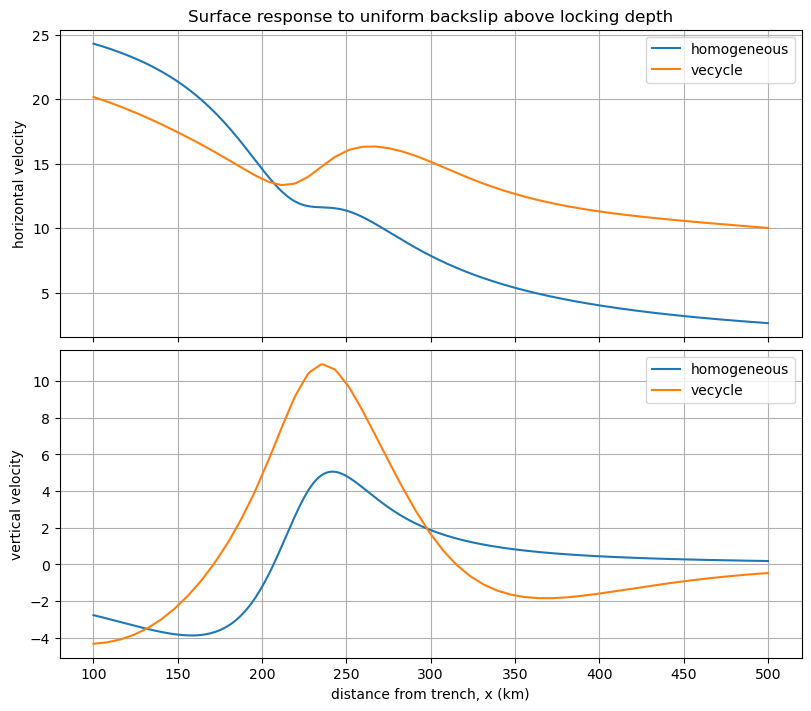

In [6]:
backslip_rate = 30 #mm/yr

# simple backslip/coupling slip distributions are generated with helper functions
# other backslip/coupling distributions can be generated and used here as well
slip_hom = uniform_backslip_above_depth(greens_hom, locking_depth_km, backslip_rate)
slip_nonhom = uniform_backslip_above_depth(greens_nonhom, locking_depth_km, backslip_rate)

#compute surface velocities from the homogeneous and non-homogeneous Greens and slip distributions
vel_hom = surface_velocity(greens_hom, slip_hom)
vel_nonhom = surface_velocity(greens_nonhom, slip_nonhom)

fig = plot_surface_velocities(xobs, vel_hom, vel_nonhom, "vecycle")
plt.show()

## 4. Synthetic inversion and model comparison

The synthetic data are generated from the **vecycle** model and then inverted twice:
- with homogeneous Green's functions
- with vecycle Green's functions

Interpretation tips:
- Compare WRMS values to assess fit quality.
- Compare recovered slip profiles to see structural bias when using a simpler Earth model.
- Noise level (`sigma_h`, `sigma_v`) and regularization (`alpha`) strongly influence recovered slip smoothness and fit.

Homogeneous inversion WRMS:     4.316
Non-homogeneous inversion WRMS: 0.960


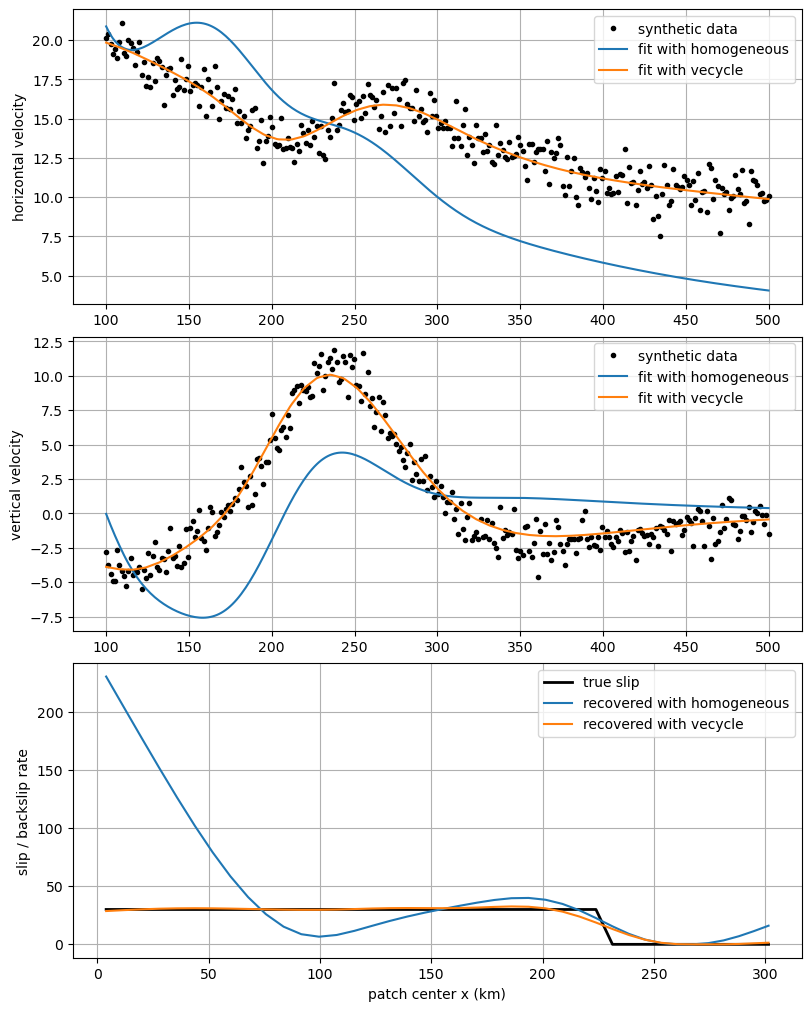

In [ ]:
# make synthetic observations from the non-homogeneous Greens and slip, then run inversions using both Greens and compare results
truth_slip = slip_nonhom.copy()
observations = make_synthetic_observations(
    greens_nonhom,
    truth_slip,
    sigma_h=1, #std dev of horizontal observation errors (mm/yr)
    sigma_v=1, #std dev of vertical observation errors (mm/yr)
    noise=True,
)


# slip inversion configuration parameters are set in the SlipInversionConfig dataclass.
cfg = gs2d.SlipInversionConfig(
    alpha=2,
    smoothing_order="second", # "first", "second", or "none"
    solver_type="nonnegative", #  "unbounded", "nonnegative", or "bounded"
    inversion_mode="slip_deficit",  #"forward_slip" or "slip_deficit
    use_vertical=True,
)

# conduct slip inversions using both Greens and compare results
out_hom = gs2d.fit_profile_slip(observations, greens_hom, cfg)
out_nonhom = gs2d.fit_profile_slip(observations, greens_nonhom, cfg)
print(f"Homogeneous inversion WRMS:     {out_hom['wrms']:.3f}")
print(f"Non-homogeneous inversion WRMS: {out_nonhom['wrms']:.3f}")


# plot inversion results for both homogeneous and non-homogeneous Greens, along with the true slip distribution used to generate the synthetic observations
fig = plot_inversion_results(
    greens_hom,
    greens_nonhom,
    truth_slip,
    out_hom,
    out_nonhom,
    "vecycle",
)
plt.show()